## **Respon Modul 2**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

Mengimport library-library seperti NumPy yang digunakan untuk melakukan komputasi numerik dan manipulasi matriks, Matplotlib yang digunakan untuk visualisasi data dalam bentuk grafik atau gambar, dan OpenCV yang dirancang untuk keperluan pengolahan citra (image processing).

Kode dibawah berfungsi untuk membaca file gambar dari direktori lokal menggunakan plt.imread, lalu menyiapkannya untuk ditampilkan melalui plt.imshow, dan terakhir menyembunyikan garis sumbu serta label koordinat dengan plt.axis('off') agar hasil visualisasinya terlihat bersih.

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

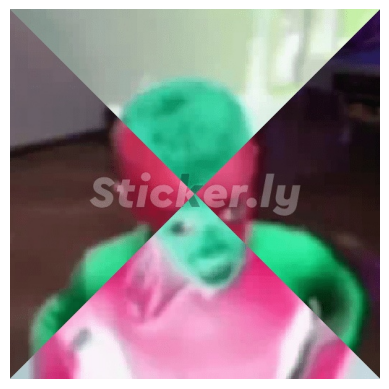

In [2]:
img_gj = plt.imread('Assets/robby_negatif.jpg')
plt.imshow(img_gj)
plt.axis('off')

In [3]:
def operasi_diagonal_n(img_bgr):
   
    img = img_bgr.copy().astype(np.int32)
    H, W = img.shape[:2]

    rows = np.arange(H).reshape(H, 1)  
    cols = np.arange(W).reshape(1, W)  

    r_norm = rows / H 
    c_norm = cols / W  

    diag_utama = r_norm > c_norm    
    anti_diag  = (r_norm + c_norm) < 1  

    mask = np.logical_xor(diag_utama, anti_diag) 

    for ch in range(3):
        img[:, :, ch][mask] = 255 - img[:, :, ch][mask]

    return img.astype(np.uint8), mask


Fungsi diatas bertujuan untuk mengubah warna gambar menjadi negatif pada bagian tertentu yang berbentuk segitiga di kiri dan kanan. Fungsi ini bekerja dengan membagi gambar secara diagonal (membentuk huruf X), lalu menggunakan logika matematika untuk menandai area mana yang harus dibalik warnanya dan mana yang tetap normal. Hasilnya, area yang ditandai akan berubah warnanya, kemudian sisanya tidak berubah, serta gambar dikembalikan ke format aslinya agar bisa ditampilkan kembali dengan benar.

Kode dibawah bertujuan untuk memproses gambar dan menampilkan perbandingan gambarnya. Pertama, gambar asli dibaca dan diproses menggunakan fungsi operasi_diagonal_n untuk mengubah bagian warnanya. Karena OpenCV membaca warna secara terbalik (BGR), kode ini mengubahnya kembali ke format warna normal (RGB) agar saat ditampilkan dengan Matplotlib, warna gambar terlihat asli dan tidak aneh. Terakhir, kedua gambar tersebut ditampilkan dalam satu bingkai, yaitu satu di sisi kiri sebagai gambar "sebelum" dan satu di sisi kanan sebagai gambar "sesudah", ditambah dengan judul dan tanpa garis sumbu koordinat agar terlihat rapi.

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

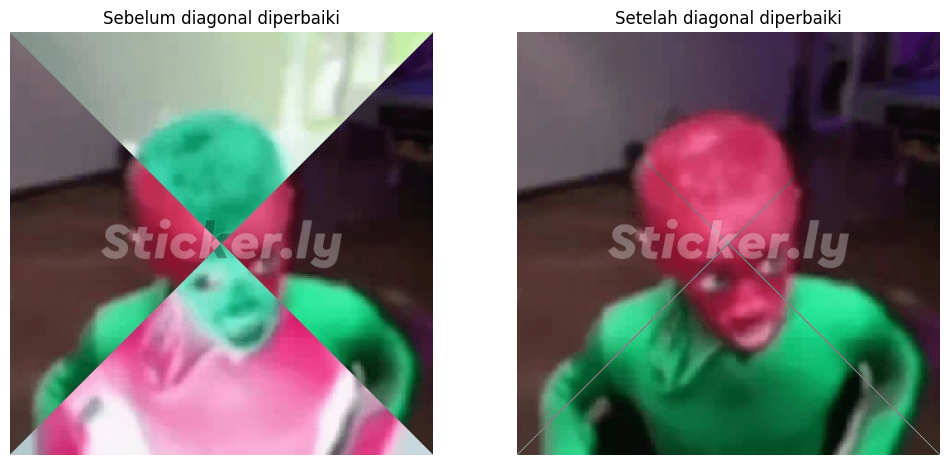

In [4]:
img_robby_gj = cv.imread('Assets/robby_negatif.jpg')

img_gj_hasil, mask_diagonal = operasi_diagonal_n(img_robby_gj)

robby_asli_rgb = cv.cvtColor(img_robby_gj, cv.COLOR_BGR2RGB)
robby_hasil_rgb = cv.cvtColor(img_gj_hasil, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(robby_asli_rgb)
plt.title("Sebelum diagonal diperbaiki")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(robby_hasil_rgb)
plt.title("Setelah diagonal diperbaiki")
plt.axis('off')

Kode dibawah digunakan untuk menampilkan 2 gambar. Baris pertama menampilkan gambar asli di posisi kiri, kemudian baris berikutnya membuat efek negatif dengan cara mengurangi angka 255 dengan warna asli (membalikkan warna). Terakhir, hasil warna yang sudah terbalik tersebut ditampilkan di posisi kanan.

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

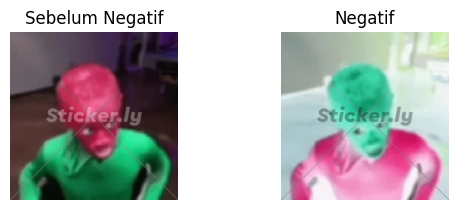

In [5]:
plt.subplot(2,2,1)
plt.imshow(robby_hasil_rgb)
plt.title("Sebelum Negatif")
plt.axis('off')

img_robby_negatif = 255 - robby_hasil_rgb
plt.subplot(2,2,2)
plt.imshow(img_robby_negatif)
plt.title("Negatif")
plt.axis('off')

In [6]:
Kecerahan = [0, 60]
h, w, c = robby_hasil_rgb.shape

for idx, brightness in enumerate(Kecerahan):
    robby_terang = np.zeros((h, w, c), dtype=robby_hasil_rgb.dtype)

for i in range(h):
    for j in range(w):
        for k in range(c):
            nilai = int(robby_hasil_rgb[i, j, k]) + brightness
            if nilai > 255:
                nilai = 255
            elif nilai < 0:
                nilai = 0
            robby_terang[i, j, k] = nilai

Kode diatas digunakan untuk mencerahkan gambar secara manual dengan cara menambah nilai setiap titik warna (piksel). Program akan memeriksa satu per satu titik warna, lalu menambahnya dengan angka tertentu (seperti 60) agar gambar terlihat lebih terang. Jika hasil penambahan melebihi batas warna maksimal (255), maka nilai tersebut akan dikunci di angka 255 supaya warna tidak rusak.

Kode dibawah digunakan untuk menampilkan perbandingan antara gambar sebelum dan sesudah dicerahkan. Gambar asli diletakkan di sebelah kiri dan gambar hasil proses pencerahan diletakkan di sebelah kanan.

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

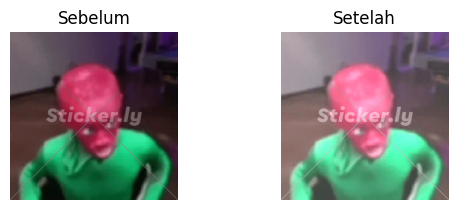

In [7]:
plt.subplot(2, 2, 1)
plt.imshow(robby_hasil_rgb)
plt.title(f"Sebelum")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(robby_terang)
plt.title(f"Setelah")
plt.axis('off')

In [8]:
def plot_histogram(histogram, title, ImgColor, new_figure=True):
    if new_figure:
        plt.figure(figsize=(10, 5))
    plt.xlabel("Intensitas Piksel")
    plt.title(title)
    plt.ylabel("Jumlah Piksel")
    plt.bar(range(256), histogram, color=ImgColor, width=0.8, alpha=0.7, label=title)

Fungsi diatas digunakan untuk membuat grafik histogram yang menunjukkan persebaran warna pada gambar. Fungsi tersebut akan menampiljan batang grafik yang mewakili jumlah setiap warna (dari 0 sampai 255), memberi label pada bagian bawah dan samping grafik agar mudah dibaca.

In [9]:
def ekualisasi_channel(channel):
    h, w  = channel.shape
    total = h * w

    hist = np.zeros(256, dtype=np.int32)
    for i in range(h):
        for j in range(w):
            hist[channel[i, j]] += 1

    cdf    = np.zeros(256, dtype=np.int32)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]

    cdf_min = cdf[cdf > 0].min()
    lut     = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        if cdf[i] > 0:
            lut[i] = round((cdf[i] - cdf_min) / (total - cdf_min) * 255)

    hasil = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            hasil[i, j] = lut[channel[i, j]]

    return hasil, hist

Fungsi diatas digunakan untuk memperbaiki kontras gambar agar pencahayaannya lebih merata dan detailnya lebih jelas. Fungsi tersebut menghitung jumlah setiap warna yang ada, membuat urutan penumpukan nilai warna, lalu menyebarkan warna-warna yang terlalu menumpuk agar mengisi seluruh ruang warna dari gelap ke terang secara lebih seimbang.

Kode dibawah digunakan untuk memproses perbaikan warna pada seluruh lapisan gambar (merah, hijau, dan biru) sekaligus membandingkan hasilnya lewat grafik. Program ini menjalankan fungsi perataan warna pada setiap warna dasar gambar, menyimpannya ke dalam daftar "sebelum" dan "sesudah", lalu menampilkan dua grafik histogram berdampingan agar bisa dilihat bagaimana penyebaran warna berubah menjadi lebih merata setelah diperbaiki.

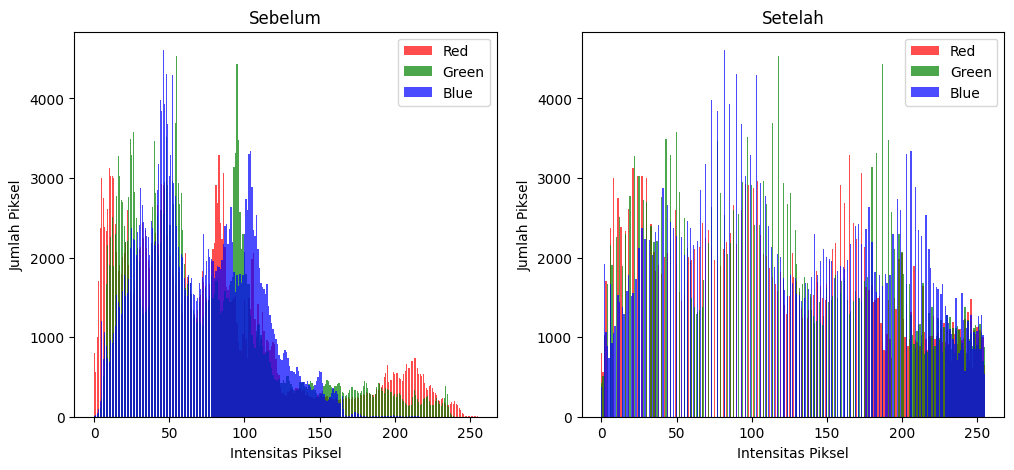

In [10]:
h, w, c   = robby_hasil_rgb.shape
h_ekualisasi = np.zeros((h, w, c), dtype=np.uint8)

h_sebelum = []
h_sesudah = []

for k in range(c):
    channel            = robby_hasil_rgb[:, :, k]
    hasil, hist        = ekualisasi_channel(channel)
    h_ekualisasi[:, :, k] = hasil

    h_sebelum.append(hist)

    h_s = np.zeros(256, dtype=np.int32)
    for i in range(h):
        for j in range(w):
            h_s[hasil[i, j]] += 1
    h_sesudah.append(h_s)

warna = ['red', 'green', 'blue']
label = ['Red', 'Green', 'Blue']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for k in range(c):
    plot_histogram(h_sebelum[k], label[k], warna[k], new_figure=False)
plt.title("Sebelum")
plt.legend()


plt.subplot(1, 2, 2)
for k in range(c):
    plot_histogram(h_sesudah[k], label[k], warna[k], new_figure=False)
plt.title("Setelah")
plt.legend()

Kode dibawah bertujuan untuk mengubah dua gambar berbeda menjadi grayscale (abu-abu) dan menampilkannya secara berdampingan. Pertama, gambar "Robby" yang sudah diproses sebelumnya diubah warnanya menjadi grayscale, lalu gambar "Pak Bahlil" dibaca dari folder dan diubah juga menjadi grayscale. Terakhir, keduanya ditampilkan dalam satu bingkai.

(np.float64(-0.5), np.float64(799.5), np.float64(532.5), np.float64(-0.5))

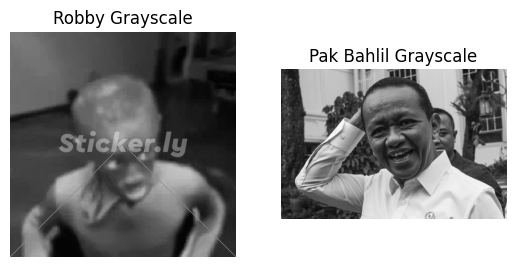

In [11]:
robby_grayscale = cv.cvtColor(robby_hasil_rgb, cv.COLOR_RGB2GRAY)
plt.subplot(1, 2, 1)
plt.imshow(robby_grayscale, cmap='gray')
plt.title('Robby Grayscale')
plt.axis('off')

pak_bahlil_gray = cv.cvtColor(cv.imread("Assets/bahlul.jpg"), cv.COLOR_BGR2GRAY)
plt.subplot(1, 2, 2)
plt.imshow(pak_bahlil_gray, cmap='gray')
plt.title('Pak Bahlil Grayscale')
plt.axis('off')

In [12]:
def spesifikasi_histogram(citra_asal, citra_target):
    hist_asal = np.zeros(256, dtype=int)
    h_asal, w_asal = citra_asal.shape
    for y in range(h_asal):
        for x in range(w_asal):
            val = int(citra_asal[y, x])
            hist_asal[val] += 1
            
    hist_target = np.zeros(256, dtype=int)
    h_target, w_target = citra_target.shape
    for y in range(h_target):
        for x in range(w_target):
            val = int(citra_target[y, x])
            hist_target[val] += 1
            
    cdf_asal = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)
    
    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]
    
    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i-1] + hist_asal[i]
        cdf_target[i] = cdf_target[i-1] + hist_target[i]
        
    cdf_asal = cdf_asal / cdf_asal[-1]
    cdf_target = cdf_target / cdf_target[-1]
    
    map_hist = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        selisih_terkecil = 1.0
        index_terbaik = 0
        for j in range(256):
            selisih = abs(cdf_asal[i] - cdf_target[j])
            if selisih < selisih_terkecil:
                selisih_terkecil = selisih
                index_terbaik = j
        map_hist[i] = index_terbaik
        
    hasil = np.zeros((h_asal, w_asal), dtype=np.uint8)
    for y in range(h_asal):
        for x in range(w_asal):
            nilai_lama = int(citra_asal[y, x])
            hasil[y, x] = map_hist[nilai_lama]
            
    return hasil

Fungsi diatas digunakan untuk meniru gaya pencahayaan dari satu gambar ke gambar lainnya (spesifikasi). Cara kerjanya adalah dengan mencocokkan persebaran warna (histogram) gambar asal agar mengikuti pola gambar target. Fungsi ini membandingkan urutan kepekatan warna dari kedua gambar, lalu mengubah setiap titik warna pada gambar asal menjadi warna yang paling mirip dengan karakter pencahayaan gambar target, sehingga kontras gambar asal berubah menjadi mirip dengan gambar target.

Kode dibawah bertujuan untuk menyamakan kontras cahaya antara dua gambar. Pertama, program menyiapkan data gambar "Robby" dan "Pak Bahlil" dengan memastikan angka warnanya sudah dibulatkan dengan rapi. Kemudian, program menggunakan fungsi yang sudah dibuat sebelumnya untuk mengubah pencahayaan gambar Robby agar mengikuti gaya atau kontras milik gambar Pak Bahlil. Terakhir, hasilnya ditampilkan dalam bentuk abu-abu.

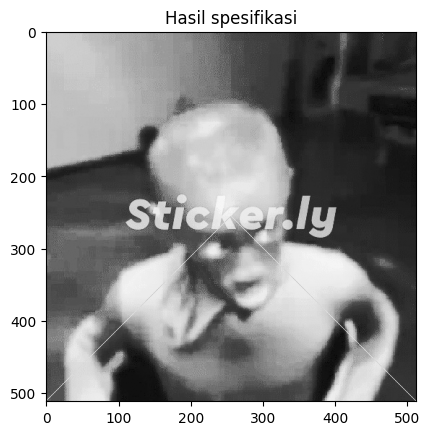

In [13]:
h1, w1 = robby_grayscale.shape[:2]
robby_ready = np.zeros((h1, w1))

for i in range(h1):
    for j in range(w1):
        robby_ready[i, j] = int(np.round(robby_grayscale[i, j]))

h2, w2 = pak_bahlil_gray.shape[:2]
p_bahlil_ready = np.zeros((h2, w2))

for i in range(h2):
    for j in range(w2):
        p_bahlil_ready[i, j] = int(np.round(pak_bahlil_gray[i, j]))

hasil_spesifikasi = spesifikasi_histogram(robby_ready, p_bahlil_ready)

plt.imshow(hasil_spesifikasi, cmap='gray')
plt.title("Hasil spesifikasi")

plt.show()

In [14]:
def buat_hist(citra):
    histogram = [0] * 256
    
    height = len(citra)
    width = len(citra[0])
    
    for i in range(height):
        for j in range(width):
            val = int(citra[i][j])
            histogram[val] += 1
            
    return histogram

Fungsi diatas digunakan untuk menghitung jumlah setiap warna yang muncul dalam sebuah gambar. Cara kerjanya yaitu dengan memeriksa setiap titik (piksel) pada gambar satu per satu, lalu mencatat dan menjumlahkan berapa kali setiap tingkat kecerahan (dari angka 0 sampai 255) muncul.

In [15]:
def plot_histogram(histogram, title, ImgColor):
    plt.figure(figsize=(10, 5))
    plt.title(title)
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    
    plt.bar(range(256), histogram, color=ImgColor)
    
    plt.show()

Fungsi diatas digunakan untuk menampilkan grafik batang yang menggambarkan sebaran warna gambar. Fungsi tersebut akan membuat jendela tampilan baru, memberikan judul serta keterangan pada sumbu grafik, lalu menggambar batang-batang yang menunjukkan seberapa banyak jumlah piksel untuk setiap tingkat kecerahan (0-255) dengan warna yang ditentukan.

Kode dibawah berfungsi untuk menampilkan grafik penyebaran warna dari hasil penggabungan gaya dua gambar sebelumnya. Pertama, program menghitung jumlah warna pada gambar hasil proses (Robby yang sudah mengikuti gaya Pak Bahlil), kemudian menampilkan hasilnya dalam bentuk grafik batang berwarna hijau.

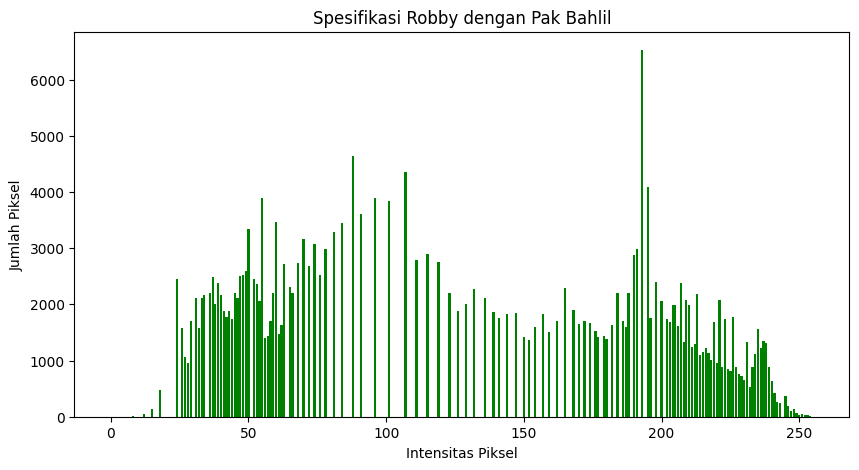

In [16]:
h_spesifikasi_histogram = buat_hist(hasil_spesifikasi)
plot_histogram(h_spesifikasi_histogram, "Spesifikasi Robby dengan Pak Bahlil", "green")